<a href="https://colab.research.google.com/github/skorrydev/notes/blob/main/11_03_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://en.wikipedia.org/wiki/List_of_TCP_and_UDP_port_numbers

nmap comm
tcp flags
tcp session finish
connect scan (-st)
syn scan(-sS)
ack scan (-sA)
fin scan (-sF)
xmass scan (-sX)
spofed sablon  
)

![image.png](
  

---


)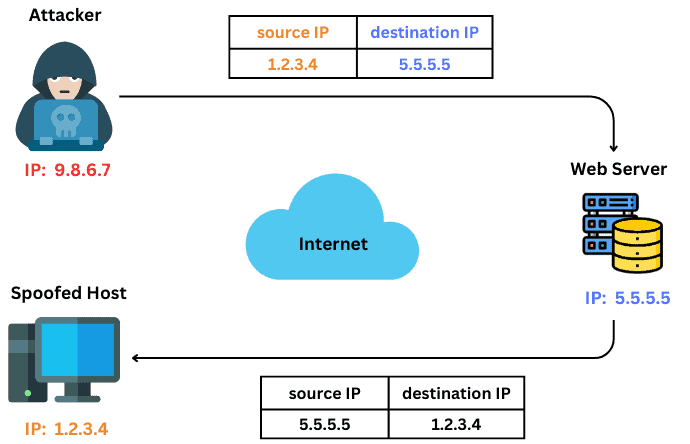

-reason
-vv
-oN
-oX
-oS
-
xsltproc cikti.xml -o cikti.html
-sO
-Pn
-f

Tarama hızı (-T0-5)
0-paranoid
1-seneaky
2-polite
3-normal
4-aggressive
5-insane


nmap script
--script=vuln
-A

// rust scan //
// zenmap //

nmap -sV -p- --script=vuln -Pn  -T4 IP_Adress

metasploit: exploit
gcc dosya.c -o xxx

use
set
options
exploit

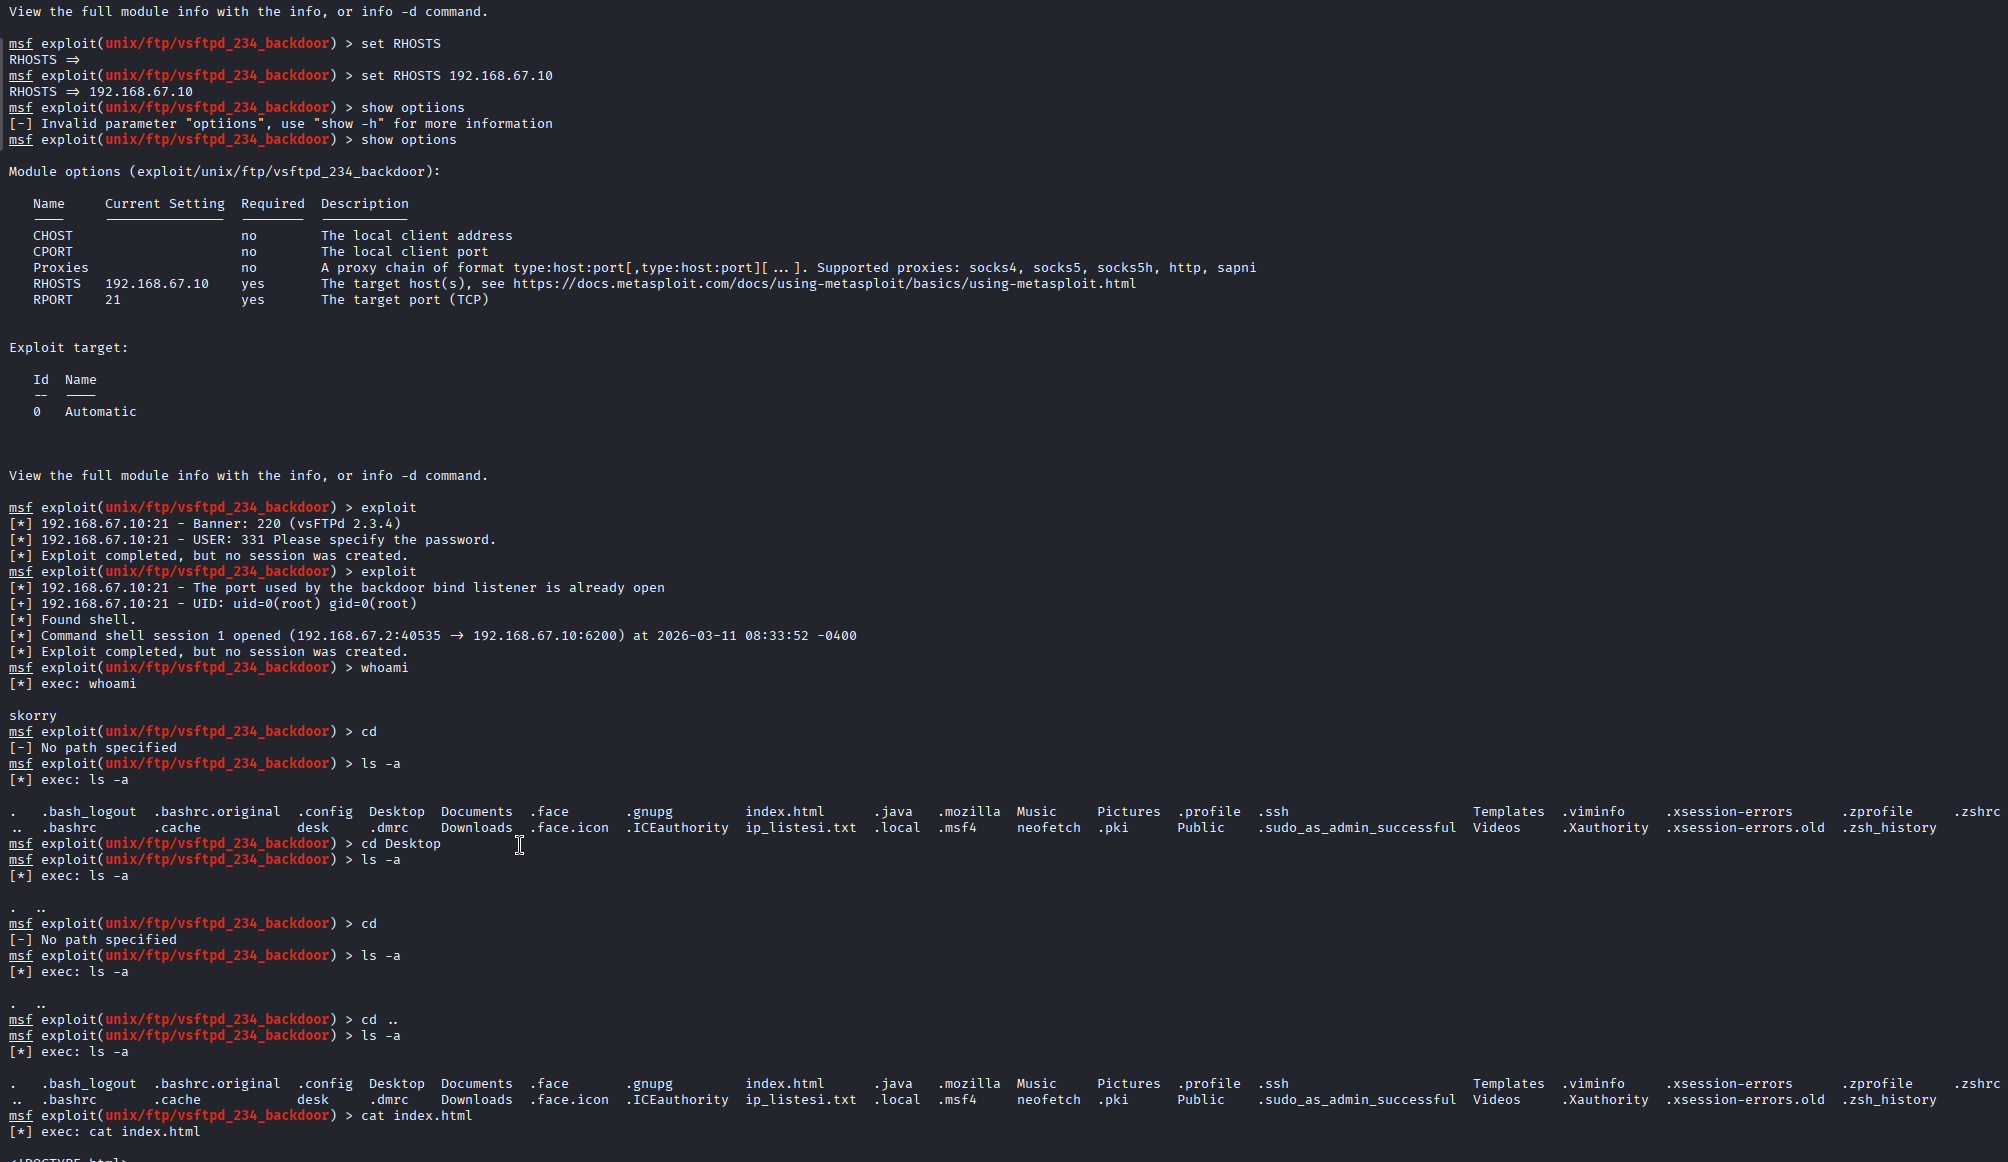

### 1. Taşıma Katmanı Protokolleri ve Port Kavramı
Ağ üzerindeki iletişim, OSI modelinin 4. katmanı olan Taşıma Katmanı'nda (Transport Layer) TCP (Transmission Control Protocol) ve UDP (User Datagram Protocol) aracılığıyla gerçekleşir.

*   **TCP**: Bağlantı yönelimli (connection-oriented), güvenilir ve veri bütünlüğünü doğrulayan bir protokoldür.
*   **UDP**: Bağlantısız (connectionless), hızlı fakat paket teslimat garantisi sunmayan bir protokoldür.

**Port Numaraları**: IANA (Internet Assigned Numbers Authority) tarafından standartlaştırılmış 0 ile 65535 arasında değişen mantıksal bağlantı noktalarıdır. İyi bilinen portlar (0-1023) HTTP (80), HTTPS (443), SSH (22) gibi temel servisleri barındırır.

### 2. TCP Bayrakları (Flags) ve Oturum Yönetimi
TCP paketlerinin başlığında (header) iletişimin durumunu kontrol eden 6 temel kontrol bayrağı bulunur. Ağ taramaları, hedef sistemin bu bayraklara verdiği tepkileri analiz ederek sistemin durumu hakkında bilgi toplar.

*   **SYN (Synchronize)**: Bağlantı başlatma talebidir.
*   **ACK (Acknowledgment)**: Alınan paketin onaylandığını belirtir.
*   **FIN (Finish)**: İletişimin bittiğini ve bağlantının sonlandırılmak istendiğini belirtir.
*   **RST (Reset)**: Bağlantının anında koparılmasını veya kapalı bir porta yapılan isteğin reddedilmesini ifade eder.
*   **PSH (Push) & URG (Urgent)**: Verinin tamponlanmadan hemen iletilmesini ve acil işlenmesini sağlar.

**TCP Oturumu (3-Way Handshake)**: İletişim SYN -> SYN-ACK -> ACK adımlarıyla başlar. İletişim bittiğinde ise FIN -> ACK adımlarıyla zarif bir şekilde (graceful teardown) kapatılır.

### 3. Nmap ile Ağ Keşfi ve Tarama Teknikleri
Nmap (Network Mapper), sistemlerin ve açık portların keşfi için kullanılan en kapsamlı araçtır. Tarama türleri, TCP bayraklarının manipülasyonuna dayanır.

*   **TCP Connect Scan (-sT)**: Hedefle tam bir 3'lü el sıkışma (3-way handshake) gerçekleştirir. En güvenilir ancak hedef sistem loglarında en çok iz bırakan taramadır.
*   **SYN Scan ("Half-open") (-sS)**: Nmap SYN gönderir, hedef SYN-ACK dönerse portun açık olduğunu anlar ve bağlantıyı tamamlamadan RST göndererek koparır. Güvenlik duvarlarına (Firewall) takılma ihtimali düşük olduğu için varsayılan ve en popüler taramadır.
*   **ACK Scan (-sA)**: Portun açık veya kapalı olduğunu değil, hedefin önünde bir güvenlik duvarı (Stateful Firewall) olup olmadığını tespit etmek için kullanılır.
*   **FIN Scan (-sF)**: Sadece FIN bayrağı ayarlanmış bir paket gönderir. Hedef sistem RFC standartlarına uyuyorsa, kapalı portlar RST döner, açık portlar tepkisiz kalır (Windows sistemlerde bu yöntem genellikle yanlış sonuç verir).
*   **Xmas Scan (-sX)**: FIN, PSH ve URG bayrakları aynı anda "yanar" (tıpkı bir Noel ağacı gibi). Amacı IPS/IDS (Saldırı Tes tes Sistemleri) atlatmak ve sistemin TCP yığınını (stack) analiz etmektir.
*   **IP Protocol Scan (-sO)**: Hedefte TCP veya UDP dışında hangi IP protokollerinin (ICMP, IGMP, IPsec vb.) çalıştığını tespit eder.
*   **Spoofed / Decoy Scan (-D)**: Taramanın kaynağını gizlemek için araya sahte (spoofed) IP adresleri ekler. Hedef sistemin loglarında, taramanın kime ait olduğu sahte IP'ler arasında kaybolur.

**Güvenlik Duvarı Atlatma Argümanları:**

*   **-Pn**: Ping atmasını engeller. Hedef ICMP (Ping) isteklerini engelliyorsa (örneğin Windows Firewall), sistemin kapalı görünmesini engellemek için tüm hedefleri "açık" varsayar.
*   **-f**: Paketleri parçalayarak (fragmentation) gönderir. Katı olmayan güvenlik duvarı veya IDS sistemlerini atlatmak için kullanılır.

### 4. Nmap Performans, Çıktı Yönetimi ve Betikler (NSE)
**Performans ve Zamanlama (Timing):**
Tarama hızı -T parametresi ile 0-5 arasında belirlenir.

*   **-T0 (Paranoid) & -T1 (Sneaky)**: Çok yavaştır, IDS sistemlerinden kaçınmak için kullanılır.
*   **-T2 (Polite)**: Ağ bant genişliğini yormamak içindir.
*   **-T3 (Normal)**: Varsayılan hızdır.
*   **-T4 (Aggressive)**: Hızlı ve modern ağlar için en ideal ve yaygın kullanımdır.
*   **-T5 (Insane)**: Çok hızlıdır ancak paket kayıpları nedeniyle yanlış sonuçlar verebilir.

**Çıktı ve Raporlama Formati:**

*   **-v veya -vv (Verbosity)**: Tarama sırasındaki detayları canlı olarak ekrana basar.
*   **--reason**: Nmap'in bir portun neden "açık" veya "kapalı" olduğuna karar verdiğini (örneğin "syn-ack alındı" veya "no-response") gösterir.
*   **-oN (Normal), -oX (XML), -oS (Script Kiddie/Leet Speak)**: Çıktıları farklı formatlarda kaydeder.
*   `xsltproc cikti.xml -o cikti.html`: Nmap'in ürettiği okunması zor XML çıktısını, yöneticilere sunulabilecek grafiksel ve düzenli bir HTML raporuna dönüştürür.

**Nmap Scripting Engine (NSE) ve Kapsamlı Tarama:**

*   **-A (Aggressive)**: İşletim sistemi tespiti (-O), versiyon tespiti (-sV), script taraması (-sC) ve traceroute işlemlerini tek parametrede birleştirir.
*   **--script=vuln**: Hedefteki açık portlarda bilinen zafiyetlerin (CVE) olup olmadığını NSE betikleri aracılığıyla otomatik kontrol eder.

**Örnek Kapsamlı Tarama Komutunun Analizi:**
`nmap -sV -p- --script=vuln -Pn -T4 IP_Adress`
Bu komut; ping atmadan (-Pn), agresif bir hızda (-T4), tüm 65535 portu (-p-) tarar, çalışan servislerin versiyonlarını bulur (-sV) ve bu servislerde bilinen bir zafiyet olup olmadığını denetler (--script=vuln).

### 5. Alternatif ve Tamamlayıcı Tarama Araçları
*   **RustScan**: Rust diliyle yazılmış, saniyeler içinde tüm 65535 portu tarayabilen son derece hızlı bir araçtır. Genellikle portları çok hızlı bulup, elde ettiği açık port listesini detaylı analiz için otomatik olarak Nmap'e aktarmak amacıyla kullanılır.
*   **Zenmap**: Nmap'in resmi grafiksel kullanıcı arayüzüdür (GUI). Özellikle ağ topolojisini görselleştirmek ve komut satırı parametrelerini ezberlemeden kullanmak isteyenler için idealdir.

### 6. Zafiyet İstismarı (Exploitation) ve Metasploit Framework (MSF)
Tarama aşamasında keşfedilen bir zafiyet, exploit (istismar kodu) kullanılarak sisteme yetkisiz erişim sağlamak için kullanılır.

**Manuel İstismar Derleme (C/C++):**
İnternetten (örneğin Exploit-DB) bulunan ham exploit kodları (genellikle .c uzantılıdır) hedef mimariye uygun olarak derlenmelidir.
`gcc dosya.c -o xxx` (C kodunu GNU Compiler Collection ile derleyerek 'xxx' adında çalıştırılabilir bir dosya oluşturur).

**Metasploit Temel Döngüsü:**
Metasploit, binlerce exploit, payload ve auxiliary modülü barındıran standart bir çatıdır. Bir zafiyet bulunduğunda şu standart adımlar izlenir:

*   `use <exploit_yolu>`: Hedef zafiyete uygun exploit modülünü seçer.
*   `options` (veya `show options`): Seçilen modülün çalışması için gerekli olan ve doldurulması gereken değişkenleri listeler.
*   `set RHOSTS <Hedef_IP>`, `set LHOST <Kendi_IP_Adresiniz>`: "Remote Host" (Kurban) ve "Local Host" (Saldırgan) gibi kritik parametreleri tanımlar.
*   `exploit` veya `run`: İstismar kodunu hedefe göndererek sistemi sömürür ve genellikle bir komut satırı (örneğin Meterpreter) elde edilmesini sağlar.